# Section 6 — Advanced Concepts in Generative AI

Four production-grade techniques on top of the LLM basics from Section 5: Structured Outputs, Function Calling, Fine-Tuning, and Retrieval-Augmented Generation — applied to four concrete actuarial use cases.

Part of the EAA seminar *Machine Learning & Generative AI: A Hands-On Guide to Actuarial Practice* by Dr. Simon Hatzesberger (8–9 June 2026, Munich).

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/simonhatzesberger/ml-genai-actuarial-practice/blob/main/notebooks/06_genai_advanced_concepts/06_genai_advanced_concepts.ipynb)

Repository: [simonhatzesberger/ml-genai-actuarial-practice](https://github.com/simonhatzesberger/ml-genai-actuarial-practice) — Code under the [MIT License](https://github.com/simonhatzesberger/ml-genai-actuarial-practice/blob/main/LICENSE).

> **Provenance.** Sections 1–4 of this notebook are adapted from *GenAI Beyond the Basics* by the German Actuarial Association (Deutsche Aktuarvereinigung) — repository [DeutscheAktuarvereinigung/GenAI_Beyond_the_Basics](https://github.com/DeutscheAktuarvereinigung/GenAI_Beyond_the_Basics). The seminar version standardises on OpenAI's Responses API and adds a 2026 deprecation note on the OpenAI fine-tuning workflow.

This notebook builds on Section 5. Each of the four sections below tackles a single advanced technique on a single actuarial example:

| Section | Technique | Actuarial example |
|---|---|---|
| §1 | Structured Outputs | Extract policy fields from a RISCBAC auto-insurance contract into a typed schema |
| §2 | Function Calling | Let an LLM query an SQLite mortality table on demand and analyse the result |
| §3 | Fine-Tuning | Adapt a model to a narrow task (complaint routing) — workflow, 2026 deprecation note, and the open-weights / LoRA alternative |
| §4 | Retrieval-Augmented Generation | Extract KPIs (2025 solvency ratio, EUR discount curve, financial-strength ratings) from Generali's annual-report PDF |

## Contents

- [Learning objectives](#learning-objectives)
- [Setup](#setup)
- [1. Structured Outputs](#1-structured-outputs)
- [2. Function Calling](#2-function-calling)
- [3. Fine-Tuning](#3-fine-tuning)
- [4. Retrieval-Augmented Generation (RAG)](#4-retrieval-augmented-generation-rag)
- [Exercises](#exercises)
- [Summary](#summary)
- [Next steps](#next-steps)
- [References](#references)

## Learning objectives

By the end of this notebook you will be able to:

- Use **Structured Outputs** to constrain an LLM's response to a Pydantic-typed JSON schema, eliminating fragile post-hoc parsing. Apply it hands-on to policy-field extraction from a (synthetic) car-insurance contract.
- Use **Function Calling** to expose deterministic Python code (database lookups, actuarial calculations) to an LLM, with the model deciding when to call. Apply it hands-on to a mortality-table query.
- Understand the **fine-tuning** workflow (data preparation → training → deployment), assess when it is the right tool, and know the modern open-weights alternative (PEFT / LoRA) given that OpenAI wound down its fine-tuning platform in May 2026.
- Build a small **RAG** pipeline (load → clean → chunk → embed → retrieve → augment → respond) and apply it to KPI extraction from a real insurer annual-report PDF.

## Setup

The cell below detects whether you are running on Google Colab. On Colab it installs the section's pinned dependencies; on a local install it assumes you have already done `pip install -r notebooks/06_genai_advanced_concepts/requirements.txt` inside your virtual environment.

For the cloud cells we use the OpenAI Responses API. Copy `.env.example` to `.env` in this folder and paste your `OPENAI_API_KEY`. If no key is set, every cloud cell skips gracefully — the dataset-loading and conceptual-code cells still run.

> **Note.** The RAG demo in §4 fetches the Generali 2025 Annual Report PDF (≈5 MB) from generali.com over the public internet at run time. If you are running offline, that cell will fail with a clear error — but the rest of the notebook is unaffected.

In [ ]:
# Detect whether we are running on Google Colab (this changes how we install deps + data).
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# On Colab, install pinned dependencies and fetch the small data files from the repo.
if IN_COLAB:
    !pip install -q -r https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/06_genai_advanced_concepts/requirements.txt
    !mkdir -p data
    !wget -q -O data/mortality_tables.sqlite https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/06_genai_advanced_concepts/data/mortality_tables.sqlite
    !wget -q -O data/riscbac_en_first10.jsonl https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/06_genai_advanced_concepts/data/riscbac_en_first10.jsonl

# Standard library
import os
import re
import json
import random
import sqlite3
import base64
from io import BytesIO
from urllib.parse import urlparse, unquote
from typing import Any, List, Literal, Optional

# Third-party scientific + LLM stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pydantic import BaseModel
from tqdm.auto import tqdm

# Fix the random seed so re-runs are reproducible.
SEED = 42
np.random.seed(SEED)

# Load the OpenAI API key from a local .env file (if present); harmless if absent.
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
HAS_OPENAI_KEY = bool(OPENAI_API_KEY)

print(f"Setup complete. Environment: {'Colab' if IN_COLAB else 'local'}.")
print(f"OpenAI key detected: {HAS_OPENAI_KEY}.")
if not HAS_OPENAI_KEY:
    print("  -> Cloud cells will skip gracefully. Local/data cells still run.")

Setup complete. Environment: local.
OpenAI key detected: True.


We reuse the same colour palette as the earlier section notebooks so figures stay visually consistent across the seminar.

In [2]:
# Seminar-wide colour palette — kept identical across all section notebooks.
PRIMARY      = "#1F3A6E"      # Navy blue
ACCENT_RED   = "#C0504D"      # Rust
ACCENT_GREEN = "#4E7C59"      # Forest
GRAY_TEXT    = "#404040"      # Dark gray

# Register the palette as the default seaborn/matplotlib theme.
sns.set_theme(
    style="whitegrid",
    palette=[PRIMARY, ACCENT_RED, ACCENT_GREEN, "#7A8DA8", "#9C7A7A"],
    rc={
        "axes.edgecolor":   GRAY_TEXT,
        "axes.labelcolor":  GRAY_TEXT,
        "xtick.color":      GRAY_TEXT,
        "ytick.color":      GRAY_TEXT,
        "axes.titlecolor":  PRIMARY,
        "axes.titleweight": "bold",
        "grid.color":       "#E5E5E5",
        "figure.facecolor": "white",
        "axes.facecolor":   "white",
    },
)

# Cloud model names (consistent with Section 5's comparison table).
MODEL_DEFAULT    = "gpt-5.4-mini"            # cheap+fast default (used in §2 and §4)
MODEL_NANO       = "gpt-5.4-nano"            # cheapest / least-capable tier (used in §1 — see §1.1)
EMBEDDINGS_MODEL = "text-embedding-3-large"  # high-quality embeddings for RAG retrieval (§4)

# OpenAI client (None if no key — every cloud cell guards on HAS_OPENAI_KEY).
if HAS_OPENAI_KEY:
    from openai import OpenAI
    client = OpenAI()
else:
    client = None

## 1. Structured Outputs

LLMs are designed to produce human-readable prose, yet many actuarial workflows require **machine-readable data** that drops straight into code, spreadsheets, or databases. Structured Outputs solve this by constraining the model to return a response that conforms to a **predefined JSON schema** rather than free-form text. When the LLM reliably fills named fields with well-specified data types, the result can be parsed deterministically — removing the need for fragile regex parsers and ad-hoc clean-up scripts.

OpenAI's `text_format` parameter (the successor to the earlier `response_format`) is the recommended way to apply Structured Outputs. Combined with Pydantic, it enforces end-to-end adherence to your JSON schema. The same workflow applies to other providers — declare the schema, embed its definition in the prompt, and instruct the model to honour it.

### Why it matters for actuaries

- **Repeatability** — pricing, reserving, and reporting pipelines receive the same field names and formats every run.
- **Interoperability** — JSON can be consumed by spreadsheets, BI dashboards, or actuarial software (Prophet, ResQ, …) with no extra transformation layer.
- **Expressiveness** — nested objects and optional fields capture complex insurance concepts such as multi-vehicle policies, layered treaties, or cash-flow waterfalls.

### How it works

1. **Define the schema** — create a Pydantic model (or JSON schema) that represents the desired output.
2. **Send prompt + schema** — pass the model class via `text_format=` (Responses API).
3. **LLM validation** — the model fills in the fields and self-checks before responding.
4. **Parse and use** — `response.output_parsed` is a fully typed Python object.

### 1.1 Use case — Policy-field extraction from a RISCBAC auto contract

The [RISCBAC corpus](https://huggingface.co/datasets/davebulaval/RISCBAC) is an open dataset of 10,000 bilingual (FR/EN) synthetic auto-insurance contracts generated from the Québec standard form. The repo ships a 10-record English sample at `data/riscbac_en_first10.jsonl`.

A RISCBAC policy embeds structured facts that we want to lift into a JSON object: policy and endorsement numbers, the insured's personal details, vehicle information, coverage limits, premium amounts, and effective dates.

We tackle the task in three progressively stricter stages, *all on the same policy text*:

1. **Stage 1** — free-form extraction (no schema, naïve baseline).
2. **Stage 2** — flat Pydantic schema (five required fields).
3. **Stage 3** — nested Pydantic schema (mirrors real policy complexity).

> **Model choice.** Throughout §1 we deliberately use the small, cheap **`gpt-5.4-nano`** model. It is the least-capable tier and more prone to inconsistent free-form output — which sharpens the contrast: even a weak, variable model returns clean, schema-valid JSON once Structured Outputs are switched on.

In [3]:
# Load the first English contract from the JSONL sample.
DATA_DIR = "data"
RISCBAC_PATH = os.path.join(DATA_DIR, "riscbac_en_first10.jsonl")

# Each line is one JSON record; we take the first contract's text.
with open(RISCBAC_PATH, "r", encoding="utf-8") as f:
    first_line = f.readline()

policy_record = json.loads(first_line)
policy_text = policy_record["text"]

# Show a short excerpt so we know what we're working with.
print(policy_text[:600] + "\n\n... [truncated]")
print(f"\n(full document: {len(policy_text):,} characters)")

October 16, 2022


ISSUE
Client N: 382787
Policy / Term:
001 / 12 month

ALWAYS BY YOUR SIDE FOR YOUR INSURANCE

Please find enclosed your insurance documents.
We recommend that you read them carefully to ensure that they are correct.
If an Important Instructions page is included with these documents, please read through it carefully because it contains crucial information regarding your coverage.
Feel free to contact us if you have any questions or comments.

CONTACT US
Customer Service
123 456-7890
1 800 123-4567
Fax: 012 345-6789
service.client@assureur.ca
8 a.m. to 8 p.m.
Monday to Friday


... [truncated]

(full document: 160,191 characters)


#### Stage 1 — Free-form extraction

We ask the model for the same five fields without any schema. Run the cell multiple times and notice the format drift: currency symbols may appear or disappear, separators change, sometimes the output is bullets and sometimes prose. Each response is human-readable but unparseable.

In [4]:
# Stage 1: ask for the five fields with NO schema — just a free-form instruction.
instructions_naive = """
You will be given a free-form description of a car insurance contract.
Your job is to extract the driver's last name, the driver's first name, the vehicle, the premium, and the contract period.
"""

if HAS_OPENAI_KEY:
    # Plain responses.create -> free-form text. Run it twice to see the format drift.
    r = client.responses.create(
        model=MODEL_NANO,
        input=policy_text,
        instructions=instructions_naive,
    )
    print(r.output_text)
else:
    print("[skipped — no OPENAI_API_KEY] Example expected output:")
    print("""Driver last name: Tremblay
Driver first name: Marie
Vehicle: 2018 Toyota Corolla LE
Premium: $1,234
Contract period: 12 months""")

- **Driver last name:** Craig  
- **Driver first name:** Ryan  
- **Vehicle:** Acura RDX 2010 (listed as “Acura - RDX - 2010”, also shown as “Vehicle 1: Acura RDX 2010”)  
- **Premium:** **1047$** (excluding tax) — annual/new 12-month policy amount  
- **Contract period:** **From 2022-12-25 to 2023-12-25** (exclusively; at 12:01 A.M. standard time)


#### Stage 2 — Flat Pydantic schema

We define a simple Pydantic model `CarInsuranceContract_basic` with five required fields and pass it via `text_format=`. The model is now constrained to return strictly valid JSON that matches the schema — no extra commentary, no missing fields, no format drift.

In [5]:
# A flat schema: five required fields, each with an explicit type.
class CarInsuranceContract_basic(BaseModel):
    driver_last_name: str
    driver_first_name: str
    vehicle_make_and_model: str
    premium: int
    contract_period: str


instructions_basic = """
Extract the following fields from the policy text and return a strictly valid JSON object
matching the `CarInsuranceContract_basic` schema:

- driver_last_name: string
- driver_first_name: string
- vehicle_make_and_model: string
- premium: integer
- contract_period: string

Do not add any commentary or extra keys.
"""

if HAS_OPENAI_KEY:
    # responses.parse + text_format= constrains the model to the schema.
    r = client.responses.parse(
        model=MODEL_NANO,
        input=policy_text,
        instructions=instructions_basic,
        text_format=CarInsuranceContract_basic,
    )
    parsed = r.output_parsed              # a fully-typed Python object
    print("Parsed Python object:", parsed)
    print()
    print("As JSON:")
    print(json.dumps(parsed.model_dump(), indent=2))
else:
    print("[skipped — no OPENAI_API_KEY]")

Parsed Python object: driver_last_name='Craig' driver_first_name='Ryan' vehicle_make_and_model='Acura RDX 2010' premium=1047 contract_period='001 / 12 month'

As JSON:
{
  "driver_last_name": "Craig",
  "driver_first_name": "Ryan",
  "vehicle_make_and_model": "Acura RDX 2010",
  "premium": 1047,
  "contract_period": "001 / 12 month"
}


#### Stage 3 — Nested Pydantic schema

A richer hierarchy mirrors real policy complexity. We add nested sub-models, optional fields, an enum-constrained month, and a list-typed field.

In [6]:
# A nested schema with sub-models, an enum-constrained month, and optional + list fields.
Month = Literal[
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]

class BirthDate(BaseModel):
    year: int
    month: Month
    day: int

class Driver(BaseModel):
    last_name: str
    first_name: str
    second_first_name: Optional[str] = None
    birth_date: BirthDate

class Vehicle(BaseModel):
    make_and_model: str
    serial_number: str

class Miscellaneous(BaseModel):
    premium: int
    tax: float
    currency: str
    damage_to_insured_vehicles: List[str]

class CarInsuranceContract_advanced(BaseModel):
    driver: Driver
    vehicle: Vehicle
    miscellaneous: Miscellaneous


instructions_advanced = """
Extract the relevant fields from the policy text and return a strictly valid JSON object
matching the `CarInsuranceContract_advanced` Pydantic schema. Do not add commentary.

If a sub-field is not present in the text, return null for optional fields (e.g. second_first_name)
or an empty list for list-typed fields.
"""

if HAS_OPENAI_KEY:
    # Even nested structures come back fully typed and validated.
    r = client.responses.parse(
        model=MODEL_NANO,
        input=policy_text,
        instructions=instructions_advanced,
        text_format=CarInsuranceContract_advanced,
    )
    parsed = r.output_parsed
    print(json.dumps(parsed.model_dump(), indent=2))
else:
    print("[skipped — no OPENAI_API_KEY]")

{
  "driver": {
    "last_name": "Craig",
    "first_name": "Ryan",
    "second_first_name": null,
    "birth_date": {
      "year": 1984,
      "month": "July",
      "day": 27
    }
  },
  "vehicle": {
    "make_and_model": "Acura - RDX - 2010",
    "serial_number": "UE4SMUNYHL50SETQ0"
  },
  "miscellaneous": {
    "premium": 1047,
    "tax": 94.22999999999999,
    "currency": "CAD",
    "damage_to_insured_vehicles": []
  }
}


### 1.2 Further actuarial applications

- **Multiclass classification** — predefined classes for document type, damage category, complaint topic, or claim severity. Always returns one of the labels you specified.
- **Fraud detection and pattern recognition** — turn narrative claims notes into structured records, ready to feed a downstream anomaly model.
- **Claims settlement automation** — extract structured fields from adjuster notes / customer communications to drive payment, reserving, and audit workflows.

For background see OpenAI's [Structured Outputs guide](https://platform.openai.com/docs/guides/structured-outputs) and the [OpenAI Cookbook structured-outputs intro](https://cookbook.openai.com/examples/structured_outputs_intro).

## 2. Function Calling

LLMs excel at understanding and generating natural-language text, but they cannot execute deterministic business logic — database look-ups, actuarial calculations, API calls — on their own. **Function Calling** (sometimes *Tool Calling*) solves this: you expose a controlled set of back-end functions to the model, and the model decides at generation time whether to:

- answer the user directly, or
- request that the application run one of the provided functions and feed the result back into the conversation.

This pattern combines the LLM's intent-recognition with the reliability, speed, and auditability of classical code.

### Why it matters for actuaries

- **Repeatability & compliance** — deterministic functions ensure that premium calculations, reserving routines, or regulatory checks are performed exactly the same way every time.
- **Traceability** — every function invocation, its arguments, and its result are logged — an audit trail.
- **Scalability** — wrap anything from a simple NPV formula to a high-performance risk engine as a callable tool.
- **Lower prompting effort** — let code do the heavy lifting; the model just decides *what* to call and *explains why*.

### How it works — the six-step round trip

1. **Application → LLM**: send the user prompt + JSON definitions of available functions.
2. **LLM reasoning**: decide whether to respond directly or invoke a tool.
3. **LLM → Application**: return either a normal assistant message or a `function_call` with `name` + `arguments`.
4. **Application layer**: parse the message and execute the requested function with the supplied arguments.
5. **Application → LLM**: re-call the LLM, passing the original prompt + the function's result.
6. **LLM reasoning + final response**: integrate the result into the answer, or trigger another tool call.

### 2.1 Use case — Mortality-table query via SQLite

The repo ships a small SQLite database (`data/mortality_tables.sqlite`) with one table named `mortality_table` holding columns `(mortality_table, gender, age, probability)`. We expose a Python function `fetch_probabilities(mortality_table, start_age, end_age, sex)` and let the LLM decide when to call it. The user prompt asks for an analysis of male mortality between ages 85 and 100 from the German private-health table *PKV-Sterbetafel 2025*; the model recognises it needs the data, calls the function, then writes a markdown analysis.

In [7]:
DB_PATH = os.path.join(DATA_DIR, "mortality_tables.sqlite")

# The deterministic back-end function we will expose to the LLM as a tool.
def fetch_probabilities(mortality_table: str, start_age: int, end_age: int, sex: str = "FEMALE"):
    """Return mortality probabilities from the SQLite DB for [start_age..end_age]."""
    sex = sex.upper()
    safe_table = mortality_table.replace("'", "''")  # basic escaping
    sql = """
        SELECT age, probability
          FROM mortality_table
         WHERE mortality_table = ?
           AND gender = ?
           AND age BETWEEN ? AND ?
         ORDER BY age
    """
    # Open a short-lived connection, run the parameterised query, return the rows.
    conn = sqlite3.connect(DB_PATH)
    try:
        cur = conn.cursor()
        cur.execute(sql, (safe_table, sex, start_age, end_age))
        rows = cur.fetchall()
    finally:
        conn.close()
    return [{"age": age, "probability": prob} for age, prob in rows]


# The JSON tool definition the LLM sees (note: this IS a JSON schema — cf. §1).
tools = [
    {
        "type": "function",
        "name": "fetch_probabilities",
        "description": "Fetch mortality probabilities from an SQLite database for an age range and gender.",
        "parameters": {
            "type": "object",
            "properties": {
                "mortality_table": {
                    "type": "string",
                    "description": "Name of the mortality table (e.g. 'PKV-Sterbetafel 2025').",
                },
                "start_age": {"type": "integer", "description": "Start age (inclusive)."},
                "end_age":   {"type": "integer", "description": "End age (inclusive)."},
                "sex": {
                    "type": "string",
                    "enum": ["MALE", "FEMALE"],
                    "description": "Gender to filter by (defaults to FEMALE).",
                    "default": "FEMALE",
                },
            },
            "required": ["mortality_table", "start_age", "end_age"],
        },
    }
]

# Quick local smoke test of the function (no API needed).
sample = fetch_probabilities("PKV-Sterbetafel 2025", start_age=85, end_age=90, sex="MALE")
print("Local function call returns:")
for row in sample:
    print(f"  age={row['age']:3d}  q={row['probability']:.6f}")

Local function call returns:
  age= 85  q=0.063080
  age= 86  q=0.073180
  age= 87  q=0.084803
  age= 88  q=0.098028
  age= 89  q=0.112913
  age= 90  q=0.129465


#### Steps 1–2 — Send prompt + tools; let the model decide

The user prompt explicitly asks for mortality probabilities in a markdown table plus a brief trend analysis. The model has the choice to either call `fetch_probabilities` or to answer from its (limited, training-cutoff) knowledge.

In [8]:
# A natural-language request that needs data the model has not memorised.
user_prompt = (
    "Please fetch the probabilities for men between age 85 and one hundred from the "
    "mortality table 'PKV-Sterbetafel 2025'. First, present the data in a markdown-formatted table. "
    "Then write two or three sentences on the trend (smoothness, monotonicity, magnitude)."
)

input_messages = [{"role": "user", "content": user_prompt}]

if HAS_OPENAI_KEY:
    # Pass the tool definitions; the model decides whether to call one.
    response = client.responses.create(
        model=MODEL_DEFAULT,
        input=input_messages,
        tools=tools,
    )
    first_chunk = response.output[0]
    if hasattr(first_chunk, "name"):
        print(f"Model decided to CALL function: {first_chunk.name}")
    else:
        print("Model returned a direct message (no function call).")
else:
    print("[skipped — no OPENAI_API_KEY] Expected: Model decided to CALL function: fetch_probabilities")

Model decided to CALL function: fetch_probabilities


#### Steps 3–4 — Extract the call and execute it locally

In [9]:
if HAS_OPENAI_KEY:
    # Extract the requested call + its JSON arguments, then run our Python function.
    tool_call = response.output[0]                # has .name, .call_id, .arguments
    args = json.loads(tool_call.arguments)
    print("Model wants to call:", tool_call.name)
    print("With arguments:", args)

    fn_result = fetch_probabilities(**args)
    print(f"\nFunction returned {len(fn_result)} rows. First few:")
    for row in fn_result[:5]:
        print(f"  age={row['age']:3d}  q={row['probability']:.6f}")
else:
    print("[skipped — no OPENAI_API_KEY]")

Model wants to call: fetch_probabilities
With arguments: {'mortality_table': 'PKV-Sterbetafel 2025', 'start_age': 85, 'end_age': 100, 'sex': 'MALE'}

Function returned 16 rows. First few:
  age= 85  q=0.063080
  age= 86  q=0.073180
  age= 87  q=0.084803
  age= 88  q=0.098028
  age= 89  q=0.112913


#### Steps 5–6 — Re-invoke the LLM with the result; produce the final analysis

In [10]:
if HAS_OPENAI_KEY:
    # Feed the function output back to the model so it can write the final answer.
    input_messages.append(tool_call)
    input_messages.append({
        "type": "function_call_output",
        "call_id": tool_call.call_id,
        "output": json.dumps(fn_result),
    })

    response_2 = client.responses.create(
        model=MODEL_DEFAULT,
        input=input_messages,
        tools=tools,
    )
    print(response_2.output_text)
else:
    print("[skipped — no OPENAI_API_KEY]")

Here are the probabilities for men aged 85 to 100 from **PKV-Sterbetafel 2025**:

| Age | Probability |
|---:|---:|
| 85 | 0.06308 |
| 86 | 0.07318 |
| 87 | 0.084803 |
| 88 | 0.098028 |
| 89 | 0.112913 |
| 90 | 0.129465 |
| 91 | 0.147647 |
| 92 | 0.167363 |
| 93 | 0.188107 |
| 94 | 0.209873 |
| 95 | 0.232032 |
| 96 | 0.24325 |
| 97 | 0.25129 |
| 98 | 0.25896 |
| 99 | 0.26621 |
| 100 | 0.27302 |

The series is perfectly monotone increasing, with no reversals. It rises fairly smoothly from age 85 through 95, then the year-to-year increases become a bit smaller, so the curve continues upward but with a mild flattening. The magnitude is substantial overall: the probability increases from about 6.3% at age 85 to about 27.3% at age 100.


### 2.2 Further actuarial applications

- **Dynamic tariff calculation** — business users change coverages / deductibles in chat; the model calls a tariff function for instant requotes.
- **Customer service with live data** — renewal dates, payment history, coverage details — answered from the policy DB, not from training data.
- **Risk scenario simulation** — risk manager describes a stress test in natural language; the model calls a Monte Carlo engine.
- **Automated policy issuance** — underwriter describes the case; the model calls a policy-generation function and returns a draft.

For background see OpenAI's [Function Calling guide](https://platform.openai.com/docs/guides/function-calling) and the [Cookbook example](https://cookbook.openai.com/examples/how_to_call_functions_with_chat_models).

> **Connection to Structured Outputs.** Tool definitions are themselves JSON schemas. Once you are comfortable with §1, the `parameters` block of a tool definition is just a Pydantic-like schema you have already seen.

## 3. Fine-Tuning

Fine-tuning adapts a pre-trained LLM to your specific domain by continuing training on a curated set of labelled examples. Unlike prompt engineering — where you provide context and examples at inference time — fine-tuning adjusts the model's internal weights, yielding permanent improvements that no longer require repeated context.

> **2026 deprecation notice.** On **2026-05-07**, OpenAI [announced](https://community.openai.com/t/openai-is-winding-down-the-fine-tuning-api-and-platform-discussion-thread/1380522) the wind-down of its self-serve fine-tuning platform. New users can no longer onboard; existing users can still create supervised fine-tuning (SFT) and DPO jobs on `gpt-4.1`, `gpt-4.1-mini`, and reinforcement fine-tuning (RFT) on `o4-mini`. **GPT-5.x models are not available for fine-tuning.** Inference on existing fine-tuned models will continue until the base model is itself deprecated.
>
> In practice this means: for new actuarial fine-tuning work in mid-2026 and beyond, the path of least resistance is **open-weights models + LoRA / PEFT** (see §3.3 below). The OpenAI workflow remains pedagogically useful as a reference, and the JSONL data format generalises directly to many other vendors.

### Why it matters for actuaries

- **Regulatory precision** — reproduce mandatory wording (Solvency II disclosures, IFRS 17 notes) verbatim; minimise hallucinations on jargon.
- **Data privacy / efficiency** — proprietary inputs (loss triangles, tariff tables) are used only during training; inference no longer needs to repeatedly expose sensitive data in the prompt.
- **Consistent decision-making** — underwriting or claims triage follow the same trained logic every time.
- **Lower cost / latency** — a fine-tuned cheap-tier model often matches frontier accuracy on a narrow task, at a fraction of the cost.

### 3.1 The three-step workflow

**Step 1 — Data preparation.** Collect representative prompt → response pairs that reflect your task, format them as JSONL. OpenAI recommends ≥50 high-quality examples per task; the absolute minimum is 10. Stratify across categories and hold out a validation split.

**Step 2 — Training.** Upload the JSONL files and launch a job. Configure hyperparameters (learning rate, batch size, epochs) if needed.

**Step 3 — Deployment & governance.** The job emits a model ID (e.g. `ft:gpt-4.1-mini:org::abc123`). Call inference with that ID via the standard Responses API.

### 3.2 Step 1 — Data preparation (small worked example)

To keep this section reproducible without Kaggle or vision setup, we use a tiny **text** classification example: routing a customer complaint to one of four queues. The same JSONL format works for any text-in / text-out task.

In [11]:
# Tiny synthetic training set: (complaint, queue) pairs. In practice you'd ship hundreds.
training_examples = [
    ("My agent never returns my calls.",                                  "SERVICE"),
    ("Forty-minute hold to reach a human.",                               "SERVICE"),
    ("Renewal premium up 35% — no explanation.",                          "PRICING"),
    ("You doubled my premium with no warning.",                           "PRICING"),
    ("Six weeks and no decision on my motor claim.",                      "CLAIMS-HANDLING"),
    ("Adjuster lowballed my contents claim.",                             "CLAIMS-HANDLING"),
    ("Can I add my partner as a named driver?",                           "OTHER"),
    ("What does 'aggregate excess' mean in my policy?",                   "OTHER"),
]

SYSTEM_PROMPT = (
    "You are a complaint router. Classify the input into exactly one of: "
    "SERVICE, CLAIMS-HANDLING, PRICING, OTHER. Return only the label."
)

# OpenAI fine-tuning expects one JSON object per line, each with a `messages` list.
def to_jsonl_record(user_text: str, assistant_label: str) -> dict:
    return {
        "messages": [
            {"role": "system",    "content": SYSTEM_PROMPT},
            {"role": "user",      "content": user_text},
            {"role": "assistant", "content": assistant_label},
        ]
    }

# Write the JSONL training file.
train_jsonl_path = "data/complaint_router_train.jsonl"
with open(train_jsonl_path, "w", encoding="utf-8") as f:
    for text, label in training_examples:
        f.write(json.dumps(to_jsonl_record(text, label)) + "\n")

print(f"Wrote {len(training_examples)} examples to {train_jsonl_path}.")
print("\nFirst record (pretty-printed):")
with open(train_jsonl_path, "r", encoding="utf-8") as f:
    print(json.dumps(json.loads(f.readline()), indent=2))

Wrote 8 examples to data/complaint_router_train.jsonl.

First record (pretty-printed):
{
  "messages": [
    {
      "role": "system",
      "content": "You are a complaint router. Classify the input into exactly one of: SERVICE, CLAIMS-HANDLING, PRICING, OTHER. Return only the label."
    },
    {
      "role": "user",
      "content": "My agent never returns my calls."
    },
    {
      "role": "assistant",
      "content": "SERVICE"
    }
  ]
}


### 3.3 Step 2 — Training (reference code — DO NOT RUN)

The cell below shows the API call shape for a supervised fine-tuning job on OpenAI. The `RUN_FINE_TUNING_JOB` flag is gated `False` by default — running this in mid-2026 will fail for new users due to the platform wind-down, and burns credit for existing users. The cell is included as documentation only.

In [12]:
RUN_FINE_TUNING_JOB = False  # Leave False unless you know what you're doing.

if RUN_FINE_TUNING_JOB and HAS_OPENAI_KEY:
    # 1) Upload the training file (and a validation file, if you have one).
    train_file = client.files.create(
        file=open(train_jsonl_path, "rb"),
        purpose="fine-tune",
    )

    # 2) Launch the supervised fine-tuning job on an allowed base model.
    #    Available in mid-2026 (existing users only): "gpt-4.1", "gpt-4.1-mini".
    job = client.fine_tuning.jobs.create(
        training_file=train_file.id,
        model="gpt-4.1-mini",
    )
    print("Submitted fine-tuning job:", job.id)
    print("Track progress via client.fine_tuning.jobs.retrieve(job.id).")
else:
    print("[skipped]  RUN_FINE_TUNING_JOB is False — this is reference code only.")
    print("           (As of 2026-05-07, OpenAI no longer accepts new fine-tuning users.)")

[skipped]  RUN_FINE_TUNING_JOB is False — this is reference code only.
           (As of 2026-05-07, OpenAI no longer accepts new fine-tuning users.)


### 3.4 The modern alternative — Open-weights + LoRA / PEFT

For new fine-tuning work in 2026, the path of least resistance is parameter-efficient fine-tuning on **open-weights** models:

- **Base model.** A capable open-weights model from Hugging Face — Llama 4 Scout, Mistral Small 4, Qwen 3.5, Gemma 4, etc. The model card lists license terms; check before commercial use.
- **Adapter method.** **LoRA** (Low-Rank Adaptation) or **QLoRA** (4-bit quantised LoRA) — training adapter matrices of a few million parameters on top of a frozen base model. Captures ~95% of full-fine-tuning quality at ~1% of the compute and memory.
- **Library.** Hugging Face [PEFT](https://huggingface.co/docs/peft) sits on top of `transformers` + `accelerate`. The training loop is ten lines of code; the rest is data preparation.
- **Serving.** Once trained, the adapter is a few-megabyte file. Serve via vLLM (production) or `transformers` (prototyping). The adapter loads on top of the base weights at startup, no merging required.
- **Data format.** Same conceptual JSONL — system / user / assistant turns — but PEFT can also consume plain `(prompt, completion)` pairs or `prompt → response` records depending on the training script.

Pseudo-code for a LoRA fine-tune on Llama-4-Scout-Instruct (illustrative; do not run here):

```python
# pip install transformers peft accelerate datasets bitsandbytes
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model
from datasets import load_dataset

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-4-Scout-17B-16E-Instruct")
model     = AutoModelForCausalLM.from_pretrained(..., load_in_4bit=True)

config = LoraConfig(r=8, lora_alpha=16, target_modules=["q_proj", "v_proj"], task_type="CAUSAL_LM")
model = get_peft_model(model, config)

ds = load_dataset("json", data_files="data/complaint_router_train.jsonl")
# ... standard HF Trainer loop ...
```


For full walk-throughs see the [PEFT documentation](https://huggingface.co/docs/peft) and the [Hugging Face fine-tuning tutorial](https://huggingface.co/learn/cookbook/en/fine_tuning_code_llm_on_single_gpu).

### 3.5 Historical case study — Car-damage classification (vision SFT)

The source notebook (Deutsche Aktuarvereinigung, *GenAI Beyond the Basics*) demonstrates vision SFT on a Kaggle car-damage dataset: ~1,500 images across six classes (crack, scratch, tire flat, dent, glass shatter, lamp broken), 60 / 20 / 20 split, fine-tune a vision-enabled GPT-4o, compare accuracy against the off-the-shelf baseline. That workflow is now historical — the OpenAI vision-SFT endpoint is closed to new users — but it remains a useful template for the equivalent task on open-weights vision models (LLaVA 1.6, Qwen2-VL, …) via PEFT.

A fuller treatment of this exact task — car-damage classification *and* localization, with data, code, and results — is available in the IAA AI Task Force case-study notebook [`car_damage_classification_and_localization.ipynb`](https://github.com/IAA-AITF/Actuarial-AI-Case-Studies/blob/main/case-studies/2025/car_damage_classification_and_localization/car_damage_classification_and_localization.ipynb).

### 3.6 Further actuarial applications

- **Tone-of-voice customisation** — claim emails, broker communications, regulator-facing notes — fine-tune for the firm's voice.
- **Domain terminology** — bake in Solvency-II / IFRS-17 / firm-internal terminology so the model uses it consistently without prompt repetition.
- **Consistent decision-making** — underwriting referrals, claims-triage decisions, fraud flags — fine-tune a small open-weights model on a labeled history.
- **Cost compression** — a LoRA-fine-tuned 7B open-weights model can match a frontier-cheap-tier model on narrow tasks at fraction of the inference cost.

## 4. Retrieval-Augmented Generation (RAG)

RAG combines an LLM with an external knowledge source so that answers are not only fluent but **factually grounded**. Instead of relying solely on what the model memorised during training, the system retrieves relevant passages from your own documents at query time and feeds them into the prompt.

This makes RAG outputs:

- **Current** — swap in a newer document and the answers update; no retraining.
- **Grounded** — the answer is built from authoritative passages you can trace back to the source.
- **Flexible** — point the same pipeline at any corpus (annual reports, policy wordings, regulations).

### The three stages

The pipeline below follows the three-stage structure of the IAA AI Task Force *GenAI-driven market comparison* case study (see [References](#references)):

1. **Preprocessing** — download the document, extract and clean its text, split it into overlapping **chunks**, and turn each chunk into an **embedding** (a semantic vector). Done once per document.
2. **Prompt augmenting** — embed the query the same way, score every chunk by cosine similarity, and **retrieve** the top-N most similar chunks as grounding context.
3. **Response generation** — combine the retrieved context with a task prompt and a **Structured-Outputs** schema (§1) so the answer comes back as a typed, machine-readable object.

> **Variants.** Microsoft's **GraphRAG** adds a knowledge graph over the chunks; **AgenticRAG** lets an agent iteratively refine the retrieval query before answering. Both are out of scope here.

### 4.1 Use case — KPI extraction from an insurer annual-report PDF

We extract three KPIs from the *Generali Group Annual Integrated Report 2025* (a ≈ 5 MB, ≈ 460-page PDF served from generali.com):

1. **Group solvency capital ratio** for 2025, plus the regulatory framework (Solvency II or SST).
2. **EUR discount-rate curve** — the discount rate by duration used for insurance-contract liabilities at year-end 2025.
3. **Insurer financial-strength ratings** — the rating and outlook reported by each agency (AM Best, Fitch, Moody's, S&P).

We run the pipeline on a **single** insurer here. The same pipeline scales horizontally to a panel of insurers for peer benchmarking — exactly what the IAA AI Task Force *GenAI-driven market comparison* case study does across AXA, Generali, and Zurich (see [References](#references)).

> **On validation.** Each extracted value can be checked against the figure published in the report (a "gold standard"). We do this informally — by eye — in a note after the results below. The market-comparison case study formalises it with a deterministic, repeated-run benchmark that scores several models against the reported ground truth; we keep this notebook to a single clean run rather than a full evaluation harness.

In [13]:
# RAG pipeline constants (mirroring the IAA market-comparison case study).
CHUNK_SIZE = 2000   # characters per chunk
OVERLAP    = 300    # characters of overlap between adjacent chunks
TOP_N      = 10     # number of chunks to retrieve per query
THRESHOLD  = 0.30   # minimum cosine similarity to keep a chunk

# The 2025 Generali Annual Integrated Report (English), served from generali.com.
GENERALI_REPORT_URL = (
    "https://www.generali.com/doc/jcr:b569c750-290c-4868-9b6f-655e0349451c/"
    "Annual%20Integrated%20Report%20and%20Consolidated%20Financial%20Statements%202025_"
    "Generali%20Group_final.pdf/lang:en/"
    "Annual_Integrated_Report_and_Consolidated_Financial_Statements_2025_Generali_Group_final.pdf"
)

print(f"Chunk size {CHUNK_SIZE}, overlap {OVERLAP}, top-N {TOP_N}, similarity cutoff {THRESHOLD}.")

Chunk size 2000, overlap 300, top-N 10, similarity cutoff 0.3.


#### Stage 1 — Preprocessing (load → clean → chunk → embed)

In [14]:
import requests
import fitz  # PyMuPDF — installed as `pymupdf`, imported as `fitz`
from sklearn.metrics.pairwise import cosine_similarity

# --- Stage 1 helpers: load -> clean -> chunk -> embed ----------------------

def load_pdf_text(url: str):
    """Download a PDF and extract its plain text. Returns (filename, raw_text)."""
    resp = requests.get(url, timeout=120)
    resp.raise_for_status()
    filename = unquote(urlparse(url).path.split("/")[-1])
    doc = fitz.open(stream=resp.content, filetype="pdf")
    raw_text = "\n".join(page.get_text() for page in doc)
    doc.close()
    return filename, raw_text


def clean_text(text: str) -> str:
    """Collapse runs of spaces/tabs and blank lines, but keep paragraph breaks."""
    text = re.sub(r"[ \t]+", " ", text)
    text = "\n".join(line.strip() for line in text.splitlines())
    text = re.sub(r"\n\s*\n+", "\n\n", text)
    return text.strip()


def create_chunks(text: str, chunk_size: int = CHUNK_SIZE, overlap: int = OVERLAP) -> List[str]:
    """Split text into overlapping fixed-size character windows (sliding window)."""
    step = chunk_size - overlap
    if step <= 0:
        raise ValueError("chunk_size must be greater than overlap")
    return [text[i: i + chunk_size] for i in range(0, len(text), step)]


def embed_texts(texts: List[str], batch_size: int = 100) -> List[List[float]]:
    """Embed a list of strings with the OpenAI embeddings API, in batches."""
    vectors: List[List[float]] = []
    for start in tqdm(range(0, len(texts), batch_size), desc="embedding chunks"):
        batch = texts[start: start + batch_size]
        resp = client.embeddings.create(model=EMBEDDINGS_MODEL, input=batch, encoding_format="float")
        vectors.extend(item.embedding for item in resp.data)
    return vectors


# --- Stage 2 helpers: retrieve + render context ----------------------------

def retrieve_top_chunks(index_df: pd.DataFrame, query_text: str,
                        top_n: int = TOP_N, threshold: float = THRESHOLD) -> pd.DataFrame:
    """Embed the query, score every chunk by cosine similarity, keep the top-N above threshold."""
    if not HAS_OPENAI_KEY or index_df.empty:
        return index_df.assign(similarity=pd.Series(dtype=float))
    # One embedding call for the query, then a single vectorised cosine-similarity pass.
    q = client.embeddings.create(model=EMBEDDINGS_MODEL, input=query_text, encoding_format="float").data[0].embedding
    qv = np.array(q).reshape(1, -1)
    matrix = np.vstack(index_df["embedding"].to_numpy())
    sims = cosine_similarity(qv, matrix)[0]
    scored = index_df.assign(similarity=sims)
    return (scored[scored["similarity"] >= threshold]
            .sort_values("similarity", ascending=False)
            .head(top_n)
            .reset_index(drop=True))


def render_context(retrieved_df: pd.DataFrame) -> str:
    """Render retrieved chunks into a numbered, readable context block for the LLM."""
    blocks = []
    for rank, row in enumerate(retrieved_df.itertuples(index=False), start=1):
        blocks.append(f"[Context {rank}] (chunk {row.chunk_id}, similarity {row.similarity:.3f})\n{row.content}")
    return "\n\n".join(blocks)

print("Helper functions defined.")

Helper functions defined.


In [15]:
# Stage 1a — download, extract, clean, and chunk the report (NO API key needed).
# First run downloads a ~5 MB PDF, so it takes ~10-30 s.
try:
    filename, raw_text = load_pdf_text(GENERALI_REPORT_URL)
    report_text = clean_text(raw_text)
    chunks = create_chunks(report_text)
    print(f"Loaded {filename}")
    print(f"  cleaned text: {len(report_text):,} characters")
    print(f"  chunks      : {len(chunks)} (size {CHUNK_SIZE}, overlap {OVERLAP})")

    # Preview the start of the extracted text to sanity-check the PDF parse.
    print("\n--- first 800 characters of extracted text ---")
    print(report_text[:800])

    # Show three random chunks to judge whether chunking preserves useful context.
    print("\n--- three random chunks ---")
    for i in random.Random(SEED).sample(range(len(chunks)), min(3, len(chunks))):
        preview = chunks[i][:240].replace("\n", " ")
        print(f"[chunk {i:03d}] {preview} …")
except Exception as e:
    print(f"PDF download or parsing failed: {e}")
    report_text, chunks = "", []

Loaded Annual_Integrated_Report_and_Consolidated_Financial_Statements_2025_Generali_Group_final.pdf
  cleaned text: 1,503,823 characters
  chunks      : 885 (size 2000, overlap 300)

--- first 800 characters of extracted text ---
ANNUAL INTEGRATED
REPORT AND CONSOLIDATED
FINANCIAL STATEMENTS
2025
194th YEAR
generali.com

ANNUAL INTEGRATED
REPORT AND CONSOLIDATED
FINANCIAL STATEMENTS
2025
Starring on the covers of the 2025 Reports is Valore Cultura, Generali Italia’s program celebrating
ten years of supporting our country’s cultural and artistic heritage, making it accessible to all,
and enhancing communities and territories across every Italian region.
Valore Cultura represents Generali Italia’s tangible commitment to social responsibility. In collaboration with
museums, theaters, and iconic heritage sites, the program supports exhibitions and educational projects
to promote and make them increasingly accessible, fostering encounters with art and mindful participation
from diverse audi

In [16]:
# Stage 1b — embed every chunk into the vector index (needs the OpenAI API).
# ~885 chunks -> a handful of batched embedding calls; cheap, but allow a minute.
if HAS_OPENAI_KEY and chunks:
    index_df = pd.DataFrame({
        "chunk_id":  [f"{i:03d}" for i in range(len(chunks))],
        "content":   chunks,
        "embedding": embed_texts(chunks),
    })
    print(f"Embedded {len(index_df)} chunks into the index with '{EMBEDDINGS_MODEL}'.")
else:
    # An empty, correctly-typed index so the downstream cells skip gracefully.
    index_df = pd.DataFrame(columns=["chunk_id", "content", "embedding"])
    print("[skipped embedding — no OPENAI_API_KEY or no chunks]")

embedding chunks:   0%|          | 0/9 [00:00<?, ?it/s]

Embedded 885 chunks into the index with 'text-embedding-3-large'.


#### Stage 2 — Prompt augmenting (define queries, retrieve top-N)

In [17]:
# A persistent system prompt that frames the structured-extraction task (§1 + RAG).
system_prompt_rag = """
You are an AI assistant specialised in extracting and structuring key financial and risk
insights from the annual reports of European insurance companies. Ground every answer in the
retrieved text snippets provided, and return the data in the exact schema requested. Identify
regulatory ratios, discount rates, and financial-strength ratings with precise numeric formats.
If a value is not clearly stated in the snippets, do not guess.
""".strip()


# A reusable human-message template: topic + instruction + guidance + retrieved context.
def build_rag_prompt(topic: str, extraction_prompt: str, context: str) -> str:
    return (
        f"Company: Generali\n"
        f"Target topic: {topic}\n\n"
        f"Extraction instruction:\n{extraction_prompt}\n\n"
        f"Additional guidance:\n"
        f"- Use only the retrieved context below.\n"
        f"- If the information is not clearly stated, do not guess.\n"
        f"- Return the requested schema only.\n\n"
        f"Retrieved context:\n{context}"
    )


# One targeted extraction prompt per KPI (a title + an instruction).
QUERIES = [
    {"label": "solvency", "title": "2025 group solvency position",
     "prompt": "Extract the group's solvency capital ratio in percentage for 2025, "
               "together with the regulatory framework (Solvency II or SST)."},
    {"label": "discount", "title": "EUR discount curve for liabilities",
     "prompt": "Extract the discount rates for insurance-contract liabilities at year-end 2025, "
               "currency EUR. For each available duration (e.g. 1, 5, 10, 20, 40 years) extract "
               "the rate in percentage. Assume non-VFA / unit-linked / liquid products if not "
               "otherwise specified."},
    {"label": "ratings", "title": "Insurer financial-strength ratings by agency",
     "prompt": "Extract the insurer financial-strength ratings (IFSR) as a list of entries, each "
               "with the rating agency (AM Best, Fitch, Moody's, or S&P), the rating, and the "
               "outlook (positive, stable, or negative)."},
]
print(f"Defined the system prompt + {len(QUERIES)} KPI extraction prompts.")

Defined the system prompt + 3 KPI extraction prompts.


In [18]:
# Retrieve the top-N grounding chunks for each KPI query.
retrieved = {}
if HAS_OPENAI_KEY and not index_df.empty:
    for q in QUERIES:
        retrieved[q["label"]] = retrieve_top_chunks(index_df, q["prompt"])

    # Interim check: inspect retrieval quality for one KPI (ratings). Are the top
    # chunks on-topic, and how high are the cosine similarities?
    preview = retrieved["ratings"][["chunk_id", "similarity", "content"]].copy()
    preview["content"] = preview["content"].str.slice(0, 90).str.replace("\n", " ", regex=False) + " …"
    print("Retrieval preview — 'financial-strength ratings' query:\n")
    print(preview.to_string(index=False))
else:
    print("[skipped — no embeddings index]")

Retrieval preview — 'financial-strength ratings' query:

chunk_id  similarity                                                                                      content
     691    0.348511 rating classes of high quality. Reinsurance contracts held: breakdown by rating (€ million …
     024    0.345668 enerali Group Moody’s upgraded Generali’s Insurer Financial Strength Rating (IFSR) from A3 …
     023    0.341186 ion to redeem, on the interest payment date falling on 21 November 2025, all outstanding n …
     690    0.330370 iscounted ultimate cumulative claim cost (Total B) 14,116 14,579 14,449 14,805 C. Net Liab …
     377    0.321854 lowing: • section B providing a brief oversight of the risk management system; • section C …
     021    0.320850 warded first position once more in the Best ESG Program category. The Central Bank of Indi …
     617    0.318311 inked to technical reserves where the investment risk is borne by the policyholders, to fi …
     510    0.317225 he same co

#### Stage 3 — Response generation (augmented prompt + Structured Outputs)

For each KPI we define a Pydantic schema, build an augmented prompt (system prompt + retrieved chunks + query + schema), and call the Responses API with `text_format=` to get back a strongly-typed Python object.

In [19]:
# One Pydantic schema per KPI (the typed shape we want back).

class SolvencyRatio(BaseModel):
    capital_ratio: int                                    # group solvency ratio in %
    regulatory_framework: Literal["Solvency II", "SST"]

class DiscountRatePoint(BaseModel):
    duration_years: int
    discount_rate_percent: float

class DiscountCurve(BaseModel):
    currency: Literal["EUR"]
    rates: List[DiscountRatePoint]

class FinancialStrengthRating(BaseModel):
    rater: Literal["AM Best", "Fitch", "Moody's", "S&P", "Other"]
    rating: str                                           # e.g. "A2", "AA-", "A+"
    outlook: Optional[Literal["positive", "stable", "negative"]] = None

class FinancialStrengthRatings(BaseModel):
    ratings: List[FinancialStrengthRating]

SCHEMAS = {"solvency": SolvencyRatio, "discount": DiscountCurve, "ratings": FinancialStrengthRatings}


def query_with_rag(label: str, topic: str, extraction_prompt: str, schema: type) -> Any:
    """Augment the prompt with retrieved context and call responses.parse with text_format=schema."""
    context = render_context(retrieved.get(label, pd.DataFrame(columns=["chunk_id", "content", "similarity"])))
    prompt = build_rag_prompt(topic, extraction_prompt, context)
    r = client.responses.parse(
        model=MODEL_DEFAULT,
        input=prompt,
        instructions=system_prompt_rag,
        text_format=schema,
        temperature=0.0,
    )
    return r.output_parsed


# Run the extraction for all three KPIs; print typed results + a one-line business summary.
results = {}
if HAS_OPENAI_KEY and retrieved:
    for q in QUERIES:
        results[q["label"]] = query_with_rag(q["label"], q["title"], q["prompt"], SCHEMAS[q["label"]])

    sol, dis, rat = results["solvency"], results["discount"], results["ratings"]

    print("=== Solvency capital ratio ===")
    print(json.dumps(sol.model_dump(), indent=2))
    print(f"Summary: {sol.capital_ratio}% under {sol.regulatory_framework}\n")

    print("=== EUR discount curve ===")
    print(json.dumps(dis.model_dump(), indent=2))
    curve = ", ".join(f"{p.duration_years}y: {p.discount_rate_percent:.2f}%" for p in dis.rates)
    print(f"Summary: {dis.currency} curve — {curve}\n")

    print("=== Financial-strength ratings ===")
    print(json.dumps(rat.model_dump(), indent=2))
    summary = "; ".join(f"{x.rater}: {x.rating}" + (f" ({x.outlook})" if x.outlook else "") for x in rat.ratings)
    print(f"Summary: {summary}")
else:
    print("[skipped — no OPENAI_API_KEY]")

=== Solvency capital ratio ===
{
  "capital_ratio": 219,
  "regulatory_framework": "Solvency II"
}
Summary: 219% under Solvency II

=== EUR discount curve ===
{
  "currency": "EUR",
  "rates": [
    {
      "duration_years": 1,
      "discount_rate_percent": 2.22
    },
    {
      "duration_years": 2,
      "discount_rate_percent": 2.3
    },
    {
      "duration_years": 3,
      "discount_rate_percent": 2.42
    },
    {
      "duration_years": 4,
      "discount_rate_percent": 2.53
    },
    {
      "duration_years": 5,
      "discount_rate_percent": 2.62
    },
    {
      "duration_years": 6,
      "discount_rate_percent": 2.7
    },
    {
      "duration_years": 7,
      "discount_rate_percent": 2.79
    },
    {
      "duration_years": 8,
      "discount_rate_percent": 2.86
    },
    {
      "duration_years": 9,
      "discount_rate_percent": 2.93
    },
    {
      "duration_years": 10,
      "discount_rate_percent": 3.0
    },
    {
      "duration_years": 15,
      "discou

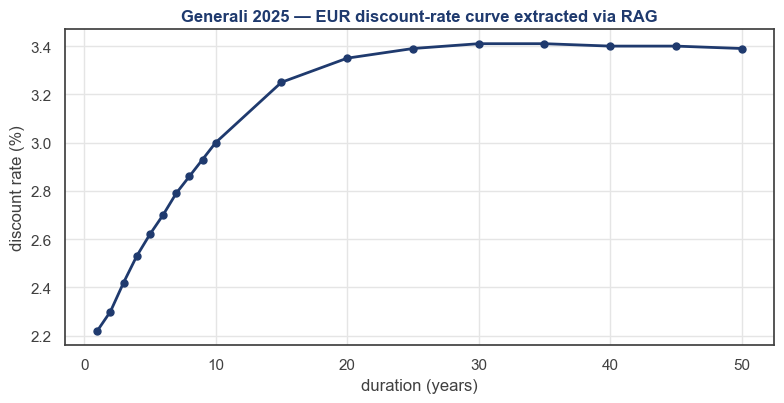

In [20]:
# Plot the extracted EUR discount-rate curve (a quick visual sanity check).
if results.get("discount") and results["discount"].rates:
    points = sorted(results["discount"].rates, key=lambda p: p.duration_years)
    xs = [p.duration_years for p in points]
    ys = [p.discount_rate_percent for p in points]
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.plot(xs, ys, marker="o", color=PRIMARY, linewidth=2, markersize=5)
    ax.set_xlabel("duration (years)")
    ax.set_ylabel("discount rate (%)")
    ax.set_title("Generali 2025 — EUR discount-rate curve extracted via RAG")
    plt.tight_layout()
    plt.show()
else:
    print("[skipped — no discount-rate result to plot]")

> **Gold-standard check (by eye).** The values published in Generali's 2025 report are: solvency ratio **219 % (Solvency II)**; financial-strength ratings **Moody's A2 (stable)**, **Fitch AA− (stable)**, **AM Best A+ (stable)**; and a EUR discount curve rising from ≈ **2.2 %** at 1 year to ≈ **3.4 %** at the long end. A correct run reproduces these. The IAA market-comparison case study replaces this informal check with a deterministic, repeated-run benchmark that scores several models against the reported ground truth across AXA, Generali, and Zurich.

### 4.2 Further actuarial applications

- **Cross-company KPI scraping** — run the same pipeline across multiple insurer annual reports for peer benchmarking.
- **Internal-document Q&A** — point RAG at your firm's policy wordings, underwriting manuals, claims-handling SOPs. Combine with §1 Structured Outputs for machine-readable answers.
- **Regulatory text retrieval** — Solvency II Delegated Acts, IFRS 17 standards, GDPR guidelines — embed once, ask many questions.
- **Reserving-committee assistant** — ground discussion questions in the actual run-off triangles, model-validation reports, and prior-year actuarial-opinion text.

For background see the [LangChain RAG overview](https://python.langchain.com/docs/tutorials/rag/), the [LlamaIndex docs](https://docs.llamaindex.ai/), and Microsoft Research's [GraphRAG paper](https://arxiv.org/abs/2404.16130).

## Exercises

Three short exercises — one for the three techniques most participants will reach for in production (Structured Outputs, Function Calling, RAG). Solutions are inlined as code cells beneath each exercise.

### Exercise 1 — Extend the Structured Output schema

Take `CarInsuranceContract_advanced` from §1 Stage 3 and add a new sub-model `Coverage` with fields:

- `coverage_type: str`   (e.g. *"Civil liability"*, *"Collision"*)
- `limit: int`           (in the policy's currency)
- `deductible: int`      (in the policy's currency)

Attach a `List[Coverage]` field named `coverages` to the top-level `CarInsuranceContract_advanced`. Re-run the extraction on the same policy text and print the result.

In [21]:
# Solution
# Extend the nested schema with a list of coverage objects.

class Coverage(BaseModel):
    coverage_type: str
    limit: int
    deductible: int

class CarInsuranceContract_extended(BaseModel):
    driver: Driver
    vehicle: Vehicle
    miscellaneous: Miscellaneous
    coverages: List[Coverage]


instructions_extended = """
Extract all relevant fields from the policy text and return a strictly valid JSON object
matching the `CarInsuranceContract_extended` schema. For `coverages`, include every
coverage section you can identify with its limit (currency-amount) and deductible
(currency-amount). Use 0 for deductible if none is stated. Do not add commentary.
"""

if HAS_OPENAI_KEY:
    r = client.responses.parse(
        model=MODEL_NANO,
        input=policy_text,
        instructions=instructions_extended,
        text_format=CarInsuranceContract_extended,
    )
    print(json.dumps(r.output_parsed.model_dump(), indent=2))
else:
    print("[skipped — no OPENAI_API_KEY]")

{
  "driver": {
    "last_name": "Craig",
    "first_name": "Ryan",
    "second_first_name": null,
    "birth_date": {
      "year": 1984,
      "month": "July",
      "day": 27
    }
  },
  "vehicle": {
    "make_and_model": "Acura RDX 2010",
    "serial_number": "UE4SMUNYHL50SETQ0"
  },
  "miscellaneous": {
    "premium": 1047,
    "tax": 94.23,
    "currency": "CAD",
    "damage_to_insured_vehicles": [
      "Section B - DAMAGE TO INSURED VEHICLES: Protection 1 All risks Included; Protection 2 Risk of collision and rollover Deductible 1000$ per claim; Protection 3 All risks except collision or rollover Deductible 500$ per claim; Protection 4 Specific risks Included"
    ]
  },
  "coverages": [
    {
      "coverage_type": "Section A - Civil liability - Property damage or bodily injury to another person (Amount of insurance)",
      "limit": 1000000,
      "deductible": 0
    },
    {
      "coverage_type": "Section B - Damage to insured vehicles - Protection 2 (Risk of collision and

### Exercise 2 — Add a second tool

The §2 mortality demo exposed only one function. Add a second one — `compute_life_expectancy(mortality_table, start_age, sex)` — that returns the actuarial life expectancy at `start_age` from the mortality table. (Approximation: sum of survival probabilities from `start_age` to age 100, plus a half-year-of-life correction at the end.)

Expose both tools to the LLM and ask: *"For a 65-year-old man on PKV-Sterbetafel 2025, give me the table of mortality probabilities from age 85 to 100 AND his current life expectancy."* The model should call **both** functions and integrate the results.

In [22]:
# Solution
# A second tool: curtate life expectancy from the same mortality table.

def compute_life_expectancy(mortality_table: str, start_age: int, sex: str = "FEMALE") -> float:
    """Curtate life expectancy + 0.5 correction (sum-of-survival-probabilities approach)."""
    rows = fetch_probabilities(mortality_table, start_age=start_age, end_age=120, sex=sex)
    p_survive = 1.0
    expected_years = 0.0
    for r in rows:
        q = r["probability"]
        p_survive *= (1.0 - q)
        expected_years += p_survive
    return round(expected_years + 0.5, 2)


# Expose BOTH tools to the model.
tools_extended = tools + [
    {
        "type": "function",
        "name": "compute_life_expectancy",
        "description": "Compute approximate curtate life expectancy at a given start age from a mortality table.",
        "parameters": {
            "type": "object",
            "properties": {
                "mortality_table": {"type": "string", "description": "Name of the mortality table."},
                "start_age":       {"type": "integer", "description": "Age at which to compute the life expectancy."},
                "sex":             {"type": "string", "enum": ["MALE", "FEMALE"], "default": "FEMALE"},
            },
            "required": ["mortality_table", "start_age"],
        },
    }
]

# Local sanity check.
sample_le = compute_life_expectancy("PKV-Sterbetafel 2025", start_age=65, sex="MALE")
print(f"Local life expectancy at 65 (male, PKV 2025) ≈ {sample_le} years")

# Ask a question that needs BOTH tools; loop over every function_call the model emits.
user_prompt_ex2 = (
    "For a 65-year-old man on PKV-Sterbetafel 2025, give me the mortality probabilities "
    "from age 85 to 100 in a markdown table, AND his current life expectancy at 65. "
    "Use the two available tools."
)

if HAS_OPENAI_KEY:
    messages = [{"role": "user", "content": user_prompt_ex2}]
    # First call — the model may emit one or more function_call outputs.
    response = client.responses.create(model=MODEL_DEFAULT, input=messages, tools=tools_extended)
    # Execute every requested call, append the outputs, then re-invoke for the final answer.
    name_to_fn = {"fetch_probabilities": fetch_probabilities, "compute_life_expectancy": compute_life_expectancy}
    any_calls = False
    for chunk in response.output:
        if hasattr(chunk, "name") and chunk.name in name_to_fn:
            any_calls = True
            args = json.loads(chunk.arguments)
            result = name_to_fn[chunk.name](**args)
            messages.append(chunk)
            messages.append({"type": "function_call_output", "call_id": chunk.call_id, "output": json.dumps(result)})
    if any_calls:
        final = client.responses.create(model=MODEL_DEFAULT, input=messages, tools=tools_extended)
        print(final.output_text)
    else:
        print(response.output_text)
else:
    print("[skipped — no OPENAI_API_KEY]")

Local life expectancy at 65 (male, PKV 2025) ≈ 22.22 years
Here are the mortality probabilities for a 65-year-old man on **PKV-Sterbetafel 2025** from age **85 to 100**, plus his current life expectancy at **65**.

### Mortality probabilities

| Age | Mortality probability |
|---:|---:|
| 85 | 0.06308 |
| 86 | 0.07318 |
| 87 | 0.084803 |
| 88 | 0.098028 |
| 89 | 0.112913 |
| 90 | 0.129465 |
| 91 | 0.147647 |
| 92 | 0.167363 |
| 93 | 0.188107 |
| 94 | 0.209873 |
| 95 | 0.232032 |
| 96 | 0.24325 |
| 97 | 0.25129 |
| 98 | 0.25896 |
| 99 | 0.26621 |
| 100 | 0.27302 |

### Current life expectancy at age 65

- **22.22 years**

If you want, I can also format the probabilities as percentages.


### Exercise 3 — A fourth RAG query

Add one more query to the Generali pipeline: *"What is Generali's stated approach to climate-related underwriting risk?"* Define a Pydantic schema with two fields — `summary: str` and `key_initiatives: List[str]` — and run it through the same retrieve + augment + Structured-Outputs flow.

In [23]:
# Solution
# A fourth KPI on the same pipeline: climate-related underwriting risk.

class ClimateApproach(BaseModel):
    summary: str
    key_initiatives: List[str]

query_climate = (
    "Extract Generali's stated approach to climate-related underwriting risk, "
    "including any key initiatives, frameworks, or policies explicitly mentioned."
)

if HAS_OPENAI_KEY and not index_df.empty:
    # Retrieve fresh chunks for this query, then reuse the same augment + parse flow.
    retrieved["climate"] = retrieve_top_chunks(index_df, query_climate)
    result = query_with_rag("climate", "Climate-related underwriting risk", query_climate, ClimateApproach)
    print(json.dumps(result.model_dump(), indent=2))
else:
    print("[skipped — no OPENAI_API_KEY or no embeddings index]")

{
  "summary": "Generali states that it integrates climate change considerations into its underwriting process through a Responsible Underwriting Group Guideline and related climate mitigation actions. The guideline applies to individually negotiated SME and Global Corporate & Commercial contracts and aims to reduce underwriting of risks in sensitive sectors such as thermal coal and conventional and unconventional oil & gas. Generali also says it develops insurance solutions for natural and climate-related risks, promotes adaptation and prevention measures, and uses climate-related products and services to support customers\u2019 transition and resilience. In 2025, it also established a Group Climate Hub to coordinate and accelerate climate initiatives, including climate risk modelling, prevention and adaptation, and risk accumulation monitoring.",
  "key_initiatives": [
    "Responsible Underwriting Group Guideline integrating climate change into P&C underwriting and considering clien

## Summary

Mapped back to the four learning objectives:

- **Structured Outputs** — Pydantic schemas via `text_format` give you machine-readable JSON without post-hoc parsing. Three stages (free-form → flat → nested) demonstrate the technique on a RISCBAC auto policy, deliberately using the small `gpt-5.4-nano` model to show the constraint holds even for a weak model.
- **Function Calling** — expose Python functions as tools; the model decides when to call. Six-step round trip demonstrated on a mortality-table SQLite query.
- **Fine-Tuning** — adapts the model's weights to your domain. OpenAI wound down its self-serve platform in May 2026 — for new actuarial work, use **PEFT / LoRA on open-weights** (Llama 4, Mistral Small 4, Qwen 3.5, Gemma 4).
- **RAG** — load → clean → chunk → embed → retrieve → augment → respond. Demonstrated on Generali's 2025 annual report for the group solvency ratio, the EUR discount curve, and insurer financial-strength ratings. Combine with Structured Outputs to get typed, machine-readable answers.

In production, the four techniques compose. A claims-handling assistant might use RAG to ground in the policy wording, Function Calling to look up live claim status, Structured Outputs to return a typed decision record, and a fine-tuned model for the firm's tone of voice.

## Next steps

Continue with [Section 7 — Introduction to Agentic AI](../07_agentic_ai_introduction/07_agentic_ai_introduction.ipynb), which extends the building blocks here into agent loops: a model that plans, calls tools, observes results, replans, and proceeds — autonomously, across multiple steps.

## References

**Source notebook**
- *GenAI Beyond the Basics* (Deutsche Aktuarvereinigung), 2025 — [GitHub](https://github.com/DeutscheAktuarvereinigung/GenAI_Beyond_the_Basics). Sections 1–4 of this notebook are adapted from sections 3–6 there.

**Structured Outputs**
- Introducing Structured Outputs in the API — [OpenAI Blog (Aug 2024)](https://openai.com/index/introducing-structured-outputs-in-the-api/).
- Structured Outputs guide — [OpenAI docs](https://platform.openai.com/docs/guides/structured-outputs).
- Structured Outputs Cookbook — [openai/openai-cookbook](https://cookbook.openai.com/examples/structured_outputs_intro).

**Function Calling**
- Function Calling guide — [OpenAI docs](https://platform.openai.com/docs/guides/function-calling).
- How to Call Functions with Chat Models — [OpenAI Cookbook](https://cookbook.openai.com/examples/how_to_call_functions_with_chat_models).

**Fine-Tuning**
- *OpenAI is winding down the fine-tuning API and platform* — [community announcement, 2026-05-07](https://community.openai.com/t/openai-is-winding-down-the-fine-tuning-api-and-platform-discussion-thread/1380522).
- Hugging Face PEFT documentation — [huggingface.co/docs/peft](https://huggingface.co/docs/peft).
- Hugging Face fine-tuning cookbook — [huggingface.co/learn/cookbook](https://huggingface.co/learn/cookbook/en/fine_tuning_code_llm_on_single_gpu).
- Car-damage classification & localization (IAA AI Task Force case study, 2025) — [GitHub](https://github.com/IAA-AITF/Actuarial-AI-Case-Studies/blob/main/case-studies/2025/car_damage_classification_and_localization/car_damage_classification_and_localization.ipynb). The detailed vision-SFT example referenced in §3.5.

**Retrieval-Augmented Generation**
- *GenAI-driven market comparison* (IAA AI Task Force case study, 2025) — [GitHub](https://github.com/IAA-AITF/Actuarial-AI-Case-Studies/blob/main/case-studies/2025/GenAI-driven_market_comparison/GenAI-Driven_Market_Comparison.ipynb). The §4 pipeline (prompts, chunking, interim previews, KPI schemas) is adapted from this case study.
- *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks* — Lewis et al., NeurIPS 2020. [arXiv:2005.11401](https://arxiv.org/abs/2005.11401).
- *From Local to Global: A Graph RAG Approach to Query-Focused Summarization* — Edge et al., Microsoft Research, 2024. [arXiv:2404.16130](https://arxiv.org/abs/2404.16130).
- LangChain RAG tutorial — [python.langchain.com](https://python.langchain.com/docs/tutorials/rag/).
- LlamaIndex documentation — [docs.llamaindex.ai](https://docs.llamaindex.ai/).

**Data sources used in this notebook**
- RISCBAC corpus (synthetic Québec auto-insurance contracts) — [Hugging Face](https://huggingface.co/datasets/davebulaval/RISCBAC).
- Generali Group Annual Integrated Report 2025 — [generali.com](https://www.generali.com).

All external URLs accessed 2026-05-26.

---

Part of the EAA seminar *Machine Learning & Generative AI: A Hands-On Guide to Actuarial Practice* by Dr. Simon Hatzesberger. Code under the MIT License — see [LICENSE](https://github.com/simonhatzesberger/ml-genai-actuarial-practice/blob/main/LICENSE).